# Variant Interpretation with DeepSHAP

This notebook shows how to interpret D-LDSC predictions using DeepSHAP.

In [1]:
import sys
import os
import shap
import torch
import zarr
import pickle
import pandas as pd
import numpy as np

In [2]:
sys.path.append(os.path.abspath("../.."))

In [3]:
from src.model.mlp import MLP_Baseline
from src.data.dataloader import Annotation_Dataset, GWAS_Dataset, DLDSC_DataLoader
from src.plot.finemapping_plots import plot_zscore_ld, plot_finemapping, plot_priors

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Define paths to the 4 inputs.
1. GWAS summary statistics
2. Variant annotations
3. Signed LD matrix
4. Index file

In [7]:
gwas_path = "/scratch4/davidwang/datasets/ukbb/gwas/all_traits_z_scores.parquet"
annot_path = "/scratch4/davidwang/datasets/ukbb/annotation/all/scores.meta.tsv"
ld_path = "/scratch4/davidwang/datasets/ukbb/ld_matrix/ukbb_zscores.zarr"
index_path = "/scratch4/davidwang/datasets/ukbb/index/ALL_MAF:0.01_Z:80_INFO:0.6_SQ.idx"

Create the data objects. This uses lazy loading so it should only take a few seconds.

In [8]:
# Load traits and annotation list.
traits = pd.read_csv("../all_traits.txt", header=None, dtype="str")[0].values
features = pd.read_csv("../scores.baseline.txt", header=None, sep="\t")[0].values
# Create GWAS data object.
gwas_data = GWAS_Dataset(gwas_path, traits=traits) # should reprocess these into chr and float32. Then set up indexing docs.
# Create annotation data object.
annot_data = Annotation_Dataset(pd.read_csv(annot_path, sep="\t"), features=features)
# Create LD matrix data object. 
ld_data = zarr.open(ld_path, mode="r")
# Load index
with open(index_path, "rb") as f: index = pickle.load(f)

Create the dataloader and load a window of interest.

In [9]:
window = pd.DataFrame({"chr": [8], "id": ["chr8_20000001_23000001"]})
dataloader = DLDSC_DataLoader(gwas_data, annot_data, ld_data, window, index, meta=True) 

Get the annotation, zscores, LD matrix, and metadata.

In [10]:
annot, zscore, R, _, _, metadata = next(iter(dataloader))
print(f"{metadata.shape[0]} variants in locus.")
print(f"{annot.shape[1]} annotations loaded.")

4039 variants in locus.
187 annotations loaded.


Compare results for functional and non-function finemapping from inference pass.

In [11]:
# Change to parquet files
fm_res_non_funct = pd.read_csv("/scratch4/davidwang/datasets/ukbb/finemapping/svem/ukbb_1mb_0.01maf_non_funct/chr8_20000001_23000001.tsv", sep="\t")
fm_res_funct = pd.read_csv("/scratch4/davidwang/datasets/ukbb/finemapping/svem/ukbb_1mb_0.01maf_pretrain/chr8_20000001_23000001.tsv", sep="\t")

In [12]:
trait = "blood_RED_COUNT"  # Maybe change trait to plate vol so genome browser plot is easier to understand.
zscore_height = zscore[:,np.where(traits == trait)[0]].flatten()
pip_height_non_funct = fm_res_non_funct[trait + "_PIP"]
pip_height_funct = fm_res_funct[trait + "_PIP"]
prior_height_funct = fm_res_funct[trait + "_prior"]

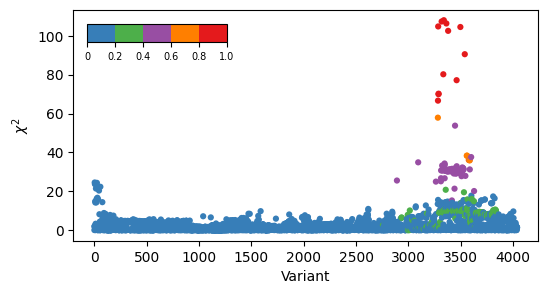

In [13]:
# Make LD optional
# use should allow chisq or p-value. 
# Fix upper right.
# Default threshold is 5e-8 or equivalent in chisq space/zscore space.
# Rename to manhatten. 
# Allow size and other asethic changes. 
# Should allow for grid construction with titles. 
plot_zscore_ld(zscore_height, R[3317,:], 50000, use_chisq=True, legend_loc="upper left")

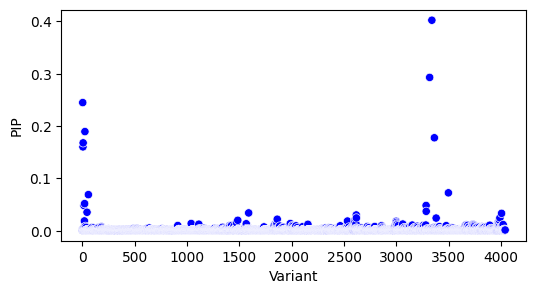

In [14]:
# This needs to have credible sets. 
plot_finemapping(torch.tensor(pip_height_non_funct))

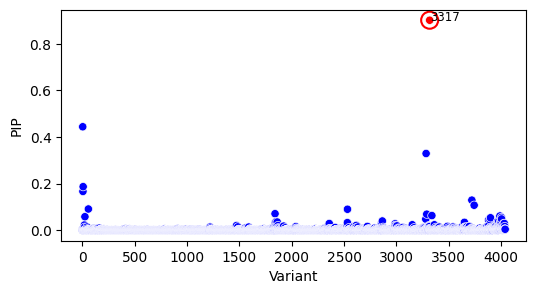

In [15]:
plot_finemapping(torch.tensor(pip_height_funct))
# Use color bar for prior? (show credible sets, show priors)

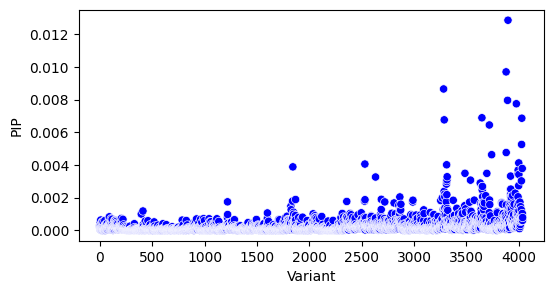

In [18]:
plot_finemapping(torch.tensor(prior_height_funct))

Functional fine-mapping helped us resolve uncertainty in a credible set! Why was this variant functional?

Load a trained model and set it to eval mode.

In [19]:
trained_model = "/scratch4/davidwang/datasets/ukbb/models/ALL_MAF:0.01_Z:80_INFO:0.6_SQ_BASELINE_PRETRAIN_LR:1e-5_VAL:1-22_SI.best.pth"
model_baseline = MLP_Baseline(187, 49)
model_baseline.load_state_dict(torch.load(trained_model, map_location=device))
model_baseline.eval()

MLP_Baseline(
  (layers): Sequential(
    (0): Linear(in_features=187, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.0, inplace=False)
    (9): Linear(in_features=32, out_features=16, bias=True)
    (10): ReLU()
    (11): Dropout(p=0.0, inplace=False)
    (12): Linear(in_features=16, out_features=49, bias=True)
  )
)

In [20]:
def plot_shap_waterfall(model, annot, cols, task, feature):
    background = annot[np.random.choice(annot.shape[0], 100, replace=False),:]
    explainer = shap.DeepExplainer(model.layers, background)
    shap_vals = explainer(annot[feature,:].reshape(1,-1))
    
    target = pd.Series(annot[feature,:].detach().cpu().numpy())
    target.index = cols

    exp = shap.Explanation(shap_vals.values[0][:,task], 
                  explainer.expected_value[task], 
                  data=target, 
                  feature_names=target.index)

    shap.plots.waterfall(exp)

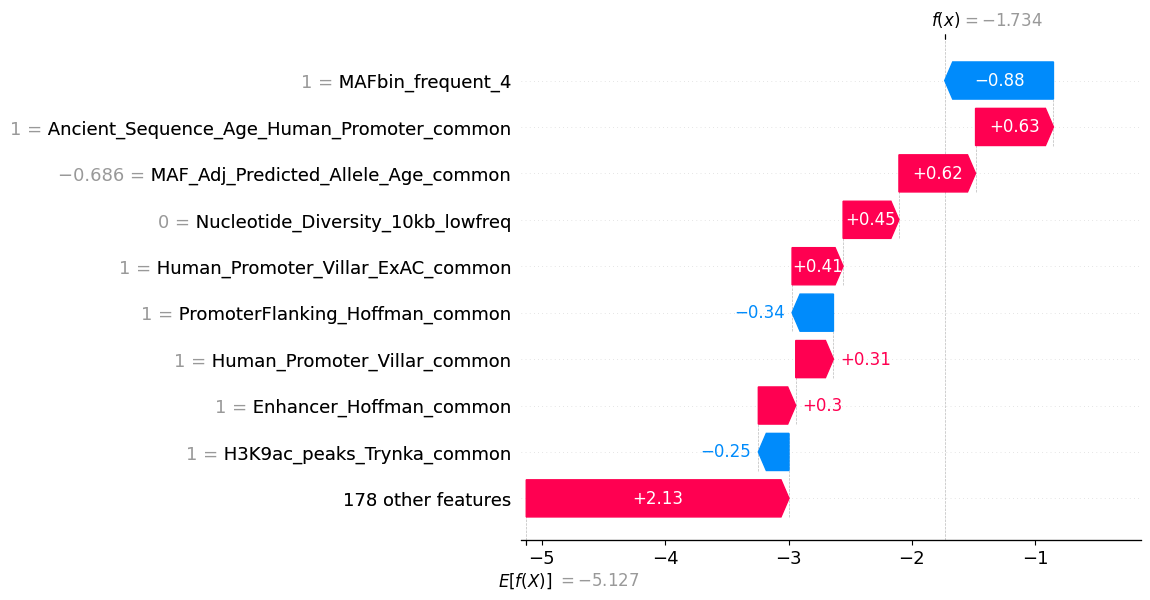

In [21]:
plot_shap_waterfall(model_baseline, annot, features, 15, 3317)

This variant is in the promoter of XPO7. View in genome browser: 
https://genome.ucsc.edu/cgi-bin/hgTracks?db=hg19&lastVirtModeType=default&lastVirtModeExtraState=&virtModeType=default&virtMode=0&nonVirtPosition=&position=chr8%3A21774937%2D21784936&hgsid=3827373537_EY2ie67tCNrTgYeYFvv7Cv9qAStm